<a href="https://colab.research.google.com/github/grooprai2025-ui/15465-Alphanomics/blob/main/01_data_and_images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 1 — Data Download & Image Construction

**15.C51 Project 2 — Technical Analysis via CNN**

This notebook does three things:
1. Downloads daily OHLCV data for a chosen universe of stocks from Yahoo Finance.
2. Constructs 64×60 OHLC chart images following Jiang, Kelly & Xiu (2023, *Journal of Finance*).
3. Saves images, labels, and metadata to a single HDF5 file in Google Drive.

**Time-ordered splits** are used throughout — no random shuffling.

**Output:** `images.h5` containing `images`, `labels`, `returns`, `dates`, `tickers`.

## 0. Environment setup

Mount Drive, install yfinance, and confirm the GPU runtime.

In [14]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/15C51_Project2'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)
print(f'Project dir: {os.getcwd()}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project dir: /content/drive/MyDrive/15C51_Project2


In [15]:
!pip install yfinance h5py --quiet

In [16]:
# Make sure utils.py is in the project directory.
# Upload it via the Files panel (left sidebar) or copy it into Drive.
assert os.path.exists('utils.py'), \
    'Upload utils.py to the project directory before continuing.'

# Enable autoreload so edits to utils.py are picked up without restarting kernel
# %load_ext autoreload
# %autoreload 2

## 1. Configuration

Edit these values to control the experiment scope. **Start small** — get the pipeline working end-to-end on a tiny universe before scaling up.

In [17]:
CONFIG = {
    # --- Asset universe ---
    'n_tickers':     50,            # start with 50; scale to 500 once working
    'use_sp500':     True,          # if False, use the manual list below
    'manual_tickers': ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA',
                       'TSLA', 'JPM', 'V', 'WMT'],

    # --- Time period ---
    'start_date':    '2010-01-01',
    'end_date':      '2025-12-31',

    # --- Image / label parameters ---
    'lookback_days': 20,            # n_days in image; image width = 3 * lookback
    'horizon_days':  5,             # forward return horizon
    'image_height':  64,
    'image_width':   60,            # 3 * lookback_days
    'stride':        1,             # 1 = generate image for every trading day

    # --- Output ---
    'output_h5':     'images.h5',
    'raw_data_pkl':  'raw_data.pkl',
}

assert CONFIG['image_width'] == 3 * CONFIG['lookback_days'], \
    'image_width must equal 3 * lookback_days'
print(CONFIG)

{'n_tickers': 50, 'use_sp500': True, 'manual_tickers': ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'TSLA', 'JPM', 'V', 'WMT'], 'start_date': '2010-01-01', 'end_date': '2025-12-31', 'lookback_days': 20, 'horizon_days': 5, 'image_height': 64, 'image_width': 60, 'stride': 1, 'output_h5': 'images.h5', 'raw_data_pkl': 'raw_data.pkl'}


## 2. Build the ticker universe

We pull the current S&P 500 constituents from Wikipedia. **Note on survivorship bias:** this includes only firms in the index *today*, which biases the sample toward survivors. For a Group Project this is an acceptable simplification — flag it as a limitation in the report. A serious replication would use a historical constituent list from CRSP/Compustat.

In [18]:
import requests
from io import StringIO
import pandas as pd

if CONFIG['use_sp500']:
    headers = {'User-Agent': 'Mozilla/5.0'}
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    html = requests.get(url, headers=headers).text
    sp500 = pd.read_html(StringIO(html))[0]
    all_tickers = sp500['Symbol'].str.replace('.', '-', regex=False).tolist()
    tickers = sorted(all_tickers)[:CONFIG['n_tickers']]
else:
    tickers = CONFIG['manual_tickers']

print(f'Universe: {len(tickers)} tickers')
print(f'First 10: {tickers[:10]}')

Universe: 50 tickers
First 10: ['A', 'AAPL', 'ABBV', 'ABNB', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM']


## 3. Download OHLCV data

We use `auto_adjust=True` so prices are split- and dividend-adjusted. Cache the raw download to Drive — re-running this cell will be instant after the first time.

In [19]:
import yfinance as yf

raw_path = CONFIG['raw_data_pkl']

if os.path.exists(raw_path):
    print(f'Loading cached data from {raw_path}')
    raw = pd.read_pickle(raw_path)
else:
    print(f'Downloading {len(tickers)} tickers from Yahoo Finance...')
    raw = yf.download(
        tickers,
        start=CONFIG['start_date'],
        end=CONFIG['end_date'],
        auto_adjust=True,
        group_by='ticker',
        progress=True,
        threads=True,
    )
    raw.to_pickle(raw_path)
    print(f'Saved to {raw_path}')

print(f'Date range: {raw.index.min().date()} to {raw.index.max().date()}')
print(f'Total trading days: {len(raw)}')

[*********************100%***********************]  50 of 50 completed


Saved to raw_data.pkl
Date range: 2010-01-04 to 2025-12-30
Total trading days: 4023


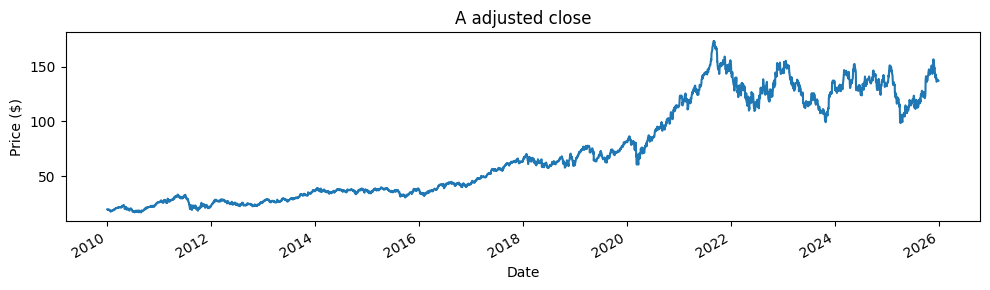

In [20]:
# Quick sanity-check: plot one ticker's price history
import matplotlib.pyplot as plt

sample_ticker = tickers[0]
if (sample_ticker, 'Close') in raw.columns:
    raw[(sample_ticker, 'Close')].plot(figsize=(10, 3), title=f'{sample_ticker} adjusted close')
    plt.ylabel('Price ($)')
    plt.tight_layout()
    plt.show()
else:
    print(f'{sample_ticker} not found in data')

## 4. Build per-ticker DataFrames

Reshape the multi-index DataFrame from yfinance into a dictionary of per-ticker OHLCV frames. Drop tickers with insufficient history.

In [21]:
import numpy as np

MIN_HISTORY = 252  # require at least 1 year of data

ticker_data = {}
for tkr in tickers:
    try:
        df = raw[tkr].copy()
    except KeyError:
        continue
    df = df.dropna(subset=['Open', 'High', 'Low', 'Close', 'Volume'])
    if len(df) < MIN_HISTORY:
        continue
    ticker_data[tkr] = df[['Open', 'High', 'Low', 'Close', 'Volume']]

print(f'Kept {len(ticker_data)} / {len(tickers)} tickers with >= {MIN_HISTORY} days')

Kept 50 / 50 tickers with >= 252 days


## 5. Generate images and labels

For each ticker, slide a `lookback_days` window over the price history. Each window produces:
- An image (constructed from the window's OHLCV)
- A forward return over `horizon_days` (the label)
- A binary up/down label
- Metadata: date and ticker

**Critical:** the label uses prices from `t+1` to `t+horizon`, while the image uses prices through `t`. This avoids look-ahead bias.

In [22]:
from utils import make_chart_image, compute_forward_return
from tqdm.auto import tqdm

lookback = CONFIG['lookback_days']
horizon = CONFIG['horizon_days']
stride = CONFIG['stride']
H, W = CONFIG['image_height'], CONFIG['image_width']

all_images = []
all_labels = []
all_returns = []
all_dates = []
all_tickers = []

for tkr, df in tqdm(ticker_data.items(), desc='Generating images'):
    fwd_ret = compute_forward_return(df['Close'], horizon=horizon)

    # Iterate over windows: window ends at index t (inclusive)
    for t in range(lookback - 1, len(df) - horizon, stride):
        window = df.iloc[t - lookback + 1 : t + 1]
        if len(window) != lookback:
            continue

        ret = fwd_ret.iloc[t]
        if pd.isna(ret):
            continue

        img = make_chart_image(window, height=H, width=W, ma_window=lookback)

        all_images.append(img)
        all_returns.append(ret)
        all_labels.append(1 if ret > 0 else 0)
        all_dates.append(df.index[t].strftime('%Y-%m-%d'))
        all_tickers.append(tkr)

print(f'Generated {len(all_images)} images')

Generating images:   0%|          | 0/50 [00:00<?, ?it/s]

Generated 189043 images


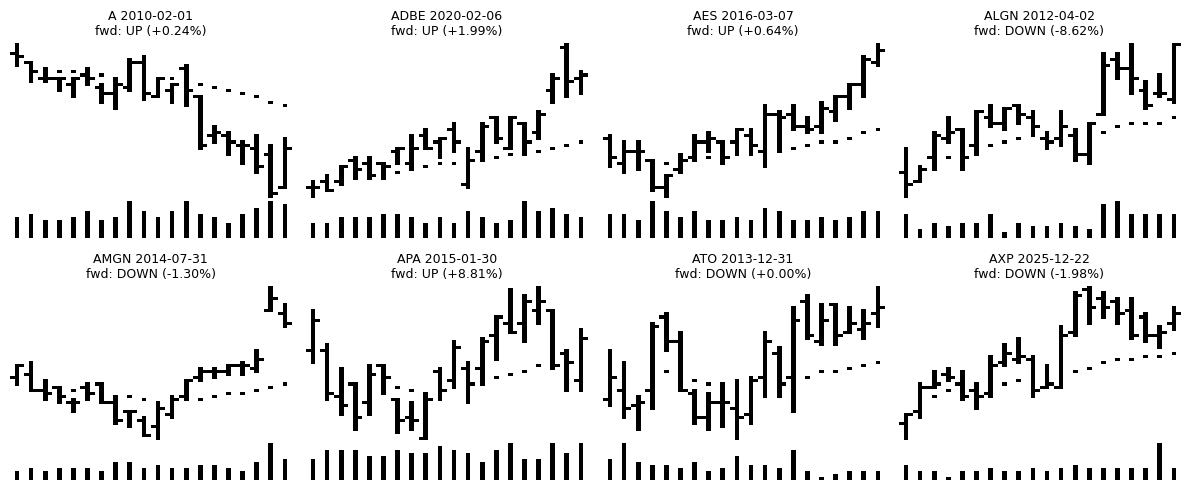

In [23]:
# Visualize a few examples
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(12, 5))
for ax, idx in zip(axes.flat, np.linspace(0, len(all_images) - 1, 8).astype(int)):
    ax.imshow(all_images[idx], cmap='gray_r', aspect='auto')
    label_str = 'UP' if all_labels[idx] == 1 else 'DOWN'
    ax.set_title(f'{all_tickers[idx]} {all_dates[idx]}\nfwd: {label_str} ({all_returns[idx]:+.2%})',
                  fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Class balance

If labels are heavily imbalanced (e.g., 60% up), the model can hit 60% accuracy by always predicting up. Check the balance before training.

In [24]:
labels_arr = np.array(all_labels)
returns_arr = np.array(all_returns)
n_up = int(labels_arr.sum())
n_total = len(labels_arr)
print(f'Up:   {n_up:>6,} ({n_up / n_total:.1%})')
print(f'Down: {n_total - n_up:>6,} ({1 - n_up / n_total:.1%})')
print(f'Mean fwd return: {returns_arr.mean():+.4f} ({returns_arr.mean() * 252 / horizon:+.2%} annualized)')

Up:   105,136 (55.6%)
Down: 83,907 (44.4%)
Mean fwd return: +0.0029 (+14.80% annualized)


## 7. Save to HDF5

Single HDF5 file is much faster than 100k+ individual PNGs on Google Drive.

In [25]:
import h5py

images_arr = np.stack(all_images)[:, np.newaxis, :, :]  # shape (N, 1, H, W)
labels_arr = np.array(all_labels, dtype=np.int8)
returns_arr = np.array(all_returns, dtype=np.float32)
dates_arr = np.array(all_dates, dtype='S10')
tickers_arr = np.array(all_tickers, dtype='S10')

out_path = CONFIG['output_h5']
with h5py.File(out_path, 'w') as f:
    f.create_dataset('images',  data=images_arr, compression='gzip', compression_opts=4)
    f.create_dataset('labels',  data=labels_arr)
    f.create_dataset('returns', data=returns_arr)
    f.create_dataset('dates',   data=dates_arr)
    f.create_dataset('tickers', data=tickers_arr)
    # Save config as attrs for reproducibility
    for k, v in CONFIG.items():
        if isinstance(v, (int, float, str, bool)):
            f.attrs[k] = v

size_mb = os.path.getsize(out_path) / 1e6
print(f'Saved {len(images_arr):,} images to {out_path} ({size_mb:.1f} MB)')

Saved 189,043 images to images.h5 (42.1 MB)


## 8. Verify the saved file

In [26]:
with h5py.File(out_path, 'r') as f:
    for k in f.keys():
        ds = f[k]
        print(f'  {k:8s}  shape={ds.shape}  dtype={ds.dtype}')
    print('  Attrs:', dict(f.attrs))

  dates     shape=(189043,)  dtype=|S10
  images    shape=(189043, 1, 64, 60)  dtype=uint8
  labels    shape=(189043,)  dtype=int8
  returns   shape=(189043,)  dtype=float32
  tickers   shape=(189043,)  dtype=|S10
  Attrs: {'end_date': '2025-12-31', 'horizon_days': np.int64(5), 'image_height': np.int64(64), 'image_width': np.int64(60), 'lookback_days': np.int64(20), 'n_tickers': np.int64(50), 'output_h5': 'images.h5', 'raw_data_pkl': 'raw_data.pkl', 'start_date': '2010-01-01', 'stride': np.int64(1), 'use_sp500': np.True_}


---

## Next steps

1. Open `02_train_cnn.ipynb` to train the CNN on these images.
2. If the universe was small (50 tickers), iterate on this notebook with `n_tickers=500` once Notebook 2 is working end-to-end.

## References

- Jiang, J., Kelly, B., & Xiu, D. (2023). (Re-)Imag(in)ing Price Trends. *Journal of Finance*, 78(6), 3193–3249.
- Image construction follows Section 2 of the above paper. See also Xiu's `Imaging Example.html` at https://dachxiu.chicagobooth.edu/.